# CPU scheduling gantt chart simulator

> importing the needed modules (and forcing the notebook to show graph)

In [70]:
%matplotlib
import matplotlib.pyplot as plt

Using matplotlib backend: module://matplotlib_inline.backend_inline


> importing the files that contains the helper functions needed by the code

In [71]:
from helper.helper_functions import remove_duplicate

## The function that generates the gantt graph from the input

> the function takes input in this format : 

```python
timeline = [ 
    [ process_id , start-time , duration ] , 
    [...] 
]
```

In [ ]:
def create_gantt_chart(time_line):

    timeline = time_line

    processes = []
    for i in timeline:
        processes.append(i[0])
    print(processes)


    y_position = {}
    position = 0
    for p in processes:
        if p in y_position:
            continue
        y_position[p] = position
        position = position+(len(remove_duplicate(processes)))
    print(y_position)

    fig, gantt_chart = plt.subplots(figsize=(20,6))

    points = []
    for process, start, duration in timeline:
        y = y_position[process]

        gantt_chart.broken_barh(
            [(start,duration)],
            (y_position[process], 2),
            facecolors = "lightblue",
            edgecolors = "lightgrey"
        )

        x_center = (start + (start+duration))/2
        y_center = y + 1

        gantt_chart.text(x_center,y_center,process,ha='center',va='center',fontsize=16)
        gantt_chart.text(start+0.1,y_center,start,ha='center',va='center')
        gantt_chart.text((start+duration)-0.1,y_center,start+duration,ha='center',va='center')


        points.append(start)
        points.append(start+duration)

    gantt_chart.set_xticks(points)

    y_ticks = []
    for y in y_position.values():
        y_ticks.append(y+1)

    print(y_ticks)
    gantt_chart.set_yticks(y_ticks)
    gantt_chart.set_yticklabels(remove_duplicate(processes))

    gantt_chart.set_xlabel("time(millisecond)")
    gantt_chart.set_ylabel("process id")
    gantt_chart.set_title("cpu scheduling gantt chart")

    gantt_chart.set_xlim(0,(timeline[-1][1]+timeline[-1][2]+1))
    gantt_chart.grid(True,color='lightgrey')


    plt.tight_layout()
    plt.show()

## 1. First Come First Serve

> the function input format : 
```py
query = [ 
    [ process_id , cpu-burst , arrival-time ] , 
    [...] 
]
```
> the return format :
```py
answer = [ 
    [ process_id , start-time , duration ] , 
    [...] 
]
```

In [73]:
def first_come_first_serve(query,context_switching=0):

    question = query
    question.sort(key=lambda x : x[2])

    answer = []

    waiting = 0

    for i in range (len(question)) :
        if i == 0 :
            waiting = question[0][2]
        elif (answer[i-1][1]+answer[i-1][2]) >= question[i][2]:
            waiting = answer[i-1][1]+answer[i-1][2]
        elif (answer[i-1][1]+answer[i-1][2]) < question[i][2]:
            waiting = question[i][2]

        answer.append([question[i][0],waiting+context_switching,question[i][1]])

    return answer

## The Main function : 

> the job is to handle the user inputs and the different function calling

In [74]:
def main(option,question):

    if option == 1 :
        answer = first_come_first_serve(question)
    else : 
        print("Wrong Input")
        return

    create_gantt_chart(answer)

## The Code Entry Point : 

> takes input from the user and gives to the main function

['P1', 'P2', 'P3']
{'P1': 0, 'P2': 3, 'P3': 6}
[1, 4, 7]


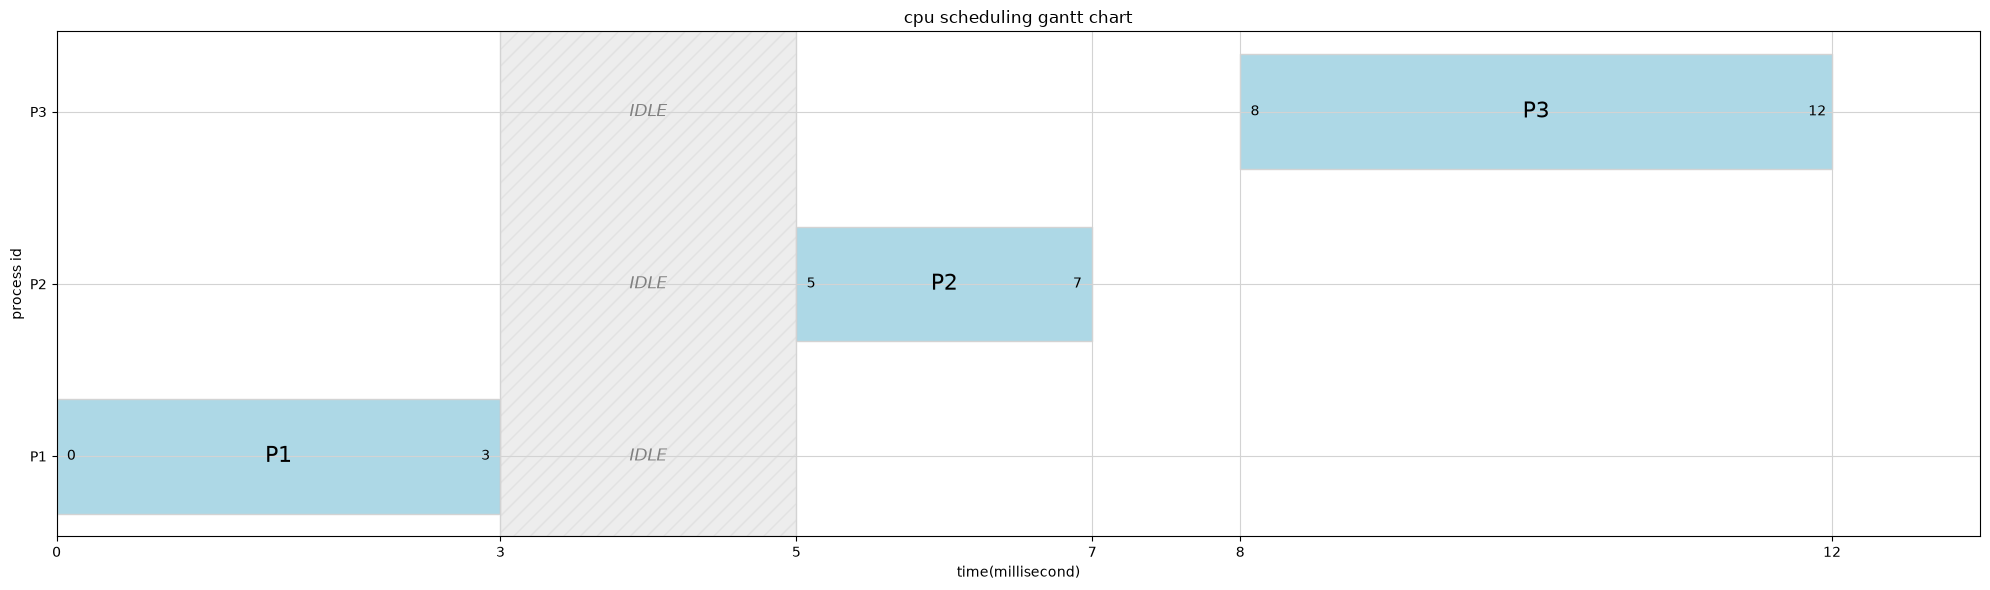

In [75]:
if __name__ == "__main__":

    # first come first serve question
    question = [
        ['P1',10,0],
        ['P2',5,15],
        ['P3',5,15],
        ['P4',10,23],
    ]

    query_1 = [["P1", 4, 0], ["P2", 3, 1], ["P3", 1, 2], ["P4", 2, 3]]
    query_2 = [["P1", 3, 0],["P2", 2, 5],["P3", 4, 8],]
    query_3 = [["P1", 3, 4],["P2", 4, 2],["P3", 2, 4],["P4", 1, 10],]

    main(1,query_2)